In [11]:
import pandas as pd

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'


df = pd.read_excel("Middle-East_aggregated_data_up_to_week_of-2026-03-21.xlsx")
df

,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE
0,2016-02-06,Middle East,Bahrain,Capital,Battles,Armed clash,1,0,69821.0,Political violence,285.0,26.1927,50.5508
1,2026-02-28,Middle East,Bahrain,Capital,Explosions/Remote violence,Air/drone strike,9,0,133690.0,Political violence,285.0,26.1927,50.5508
2,2026-03-07,Middle East,Bahrain,Capital,Explosions/Remote violence,Air/drone strike,7,1,59987.0,Political violence,285.0,26.1927,50.5508
3,2026-03-14,Middle East,Bahrain,Capital,Explosions/Remote violence,Air/drone strike,1,0,22606.0,Political violence,285.0,26.1927,50.5508
4,2026-03-21,Middle East,Bahrain,Capital,Explosions/Remote violence,Air/drone strike,1,0,NaN,Political violence,285.0,26.1927,50.5508
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145348,2024-06-29,Middle East,Yemen,West Arabian Sea,Explosions/Remote violence,Shelling/artillery/missile attack,1,0,NaN,Political violence,4187.0,13.8711,57.1292
145349,2024-07-06,Middle East,Yemen,West Arabian Sea,Explosions/Remote violence,Shelling/artillery/missile attack,1,0,NaN,Political violence,4187.0,13.8711,57.1292
145350,2024-10-26,Middle East,Yemen,West Arabian Sea,Explosions/Remote violence,Shelling/artillery/missile attack,1,0,NaN,Political violence,4187.0,13.8711,57.1292
145351,2025-04-12,Middle East,Yemen,West Arabian Sea,Strategic developments,Change to group/activity,1,0,NaN,Strategic developments,4187.0,13.8711,57.1292


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145353 entries, 0 to 145352
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   WEEK                 145353 non-null  datetime64[us]
 1   REGION               145353 non-null  str           
 2   COUNTRY              145353 non-null  str           
 3   ADMIN1               145353 non-null  str           
 4   EVENT_TYPE           145353 non-null  str           
 5   SUB_EVENT_TYPE       145353 non-null  str           
 6   EVENTS               145353 non-null  int64         
 7   FATALITIES           145353 non-null  int64         
 8   POPULATION_EXPOSURE  115253 non-null  float64       
 9   DISORDER_TYPE        145353 non-null  str           
 10  ID                   145340 non-null  float64       
 11  CENTROID_LATITUDE    145353 non-null  float64       
 12  CENTROID_LONGITUDE   145353 non-null  float64       
dtypes: datetime64[us](1), flo

In [13]:
print(df['EVENT_TYPE'].unique())
print(df['SUB_EVENT_TYPE'].unique())


<StringArray>
[                   'Battles', 'Explosions/Remote violence',
                   'Protests',                      'Riots',
     'Strategic developments', 'Violence against civilians']
Length: 6, dtype: str
<StringArray>
[                        'Armed clash',                    'Air/drone strike',
       'Remote explosive/landmine/IED',   'Shelling/artillery/missile attack',
  'Excessive force against protesters',                    'Peaceful protest',
           'Protest with intervention',                        'Mob violence',
               'Violent demonstration',                           'Agreement',
                             'Arrests',            'Change to group/activity',
               'Disrupted weapons use',        'Looting/property destruction',
                               'Other',                              'Attack',
                     'Sexual violence',                             'Grenade',
      'Abduction/forced disappearance',                 

In [14]:
df_excessive = df[df['SUB_EVENT_TYPE'] == 'Excessive force against protesters']



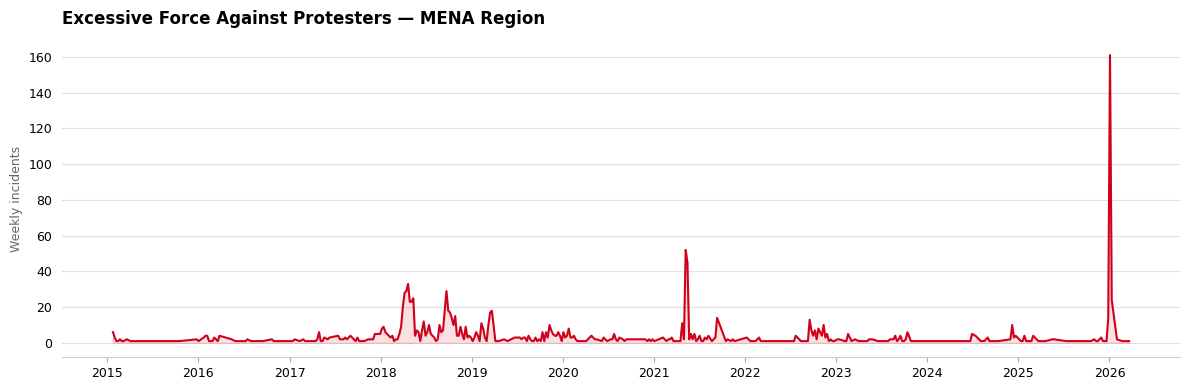

In [29]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

weekly = df_excessive.groupby('WEEK')['EVENTS'].sum()

fig, ax = plt.subplots(figsize=(12, 4))

# Line + shaded area
ax.plot(weekly.index, weekly.values, color='#D0021B', linewidth=1.5, zorder=3)
ax.fill_between(weekly.index, weekly.values, color='#D0021B', alpha=0.12)

# Gridlines — horizontal only, subtle
ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')

# Axis formatting
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', labelsize=9, color='#aaa')
ax.tick_params(axis='y', labelsize=9, left=False)
ax.set_ylabel('Weekly incidents', fontsize=9, color='#666')

# Labels
ax.set_title('Excessive Force Against Protesters — MENA Region',
             fontsize=12, fontweight='bold', loc='left', pad=12)

plt.tight_layout()
plt.savefig("violence-over-time.svg", format='svg', bbox_inches='tight')
plt.show()




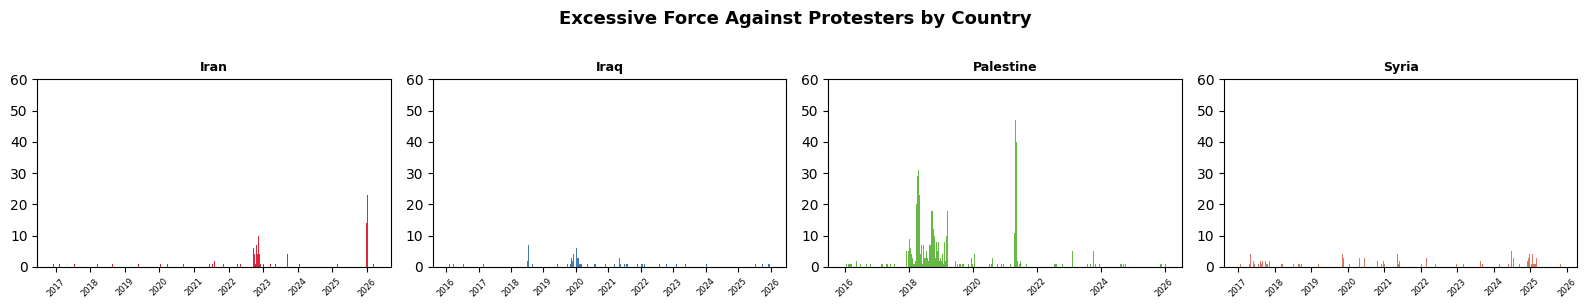

In [26]:
countries = ['Iran', 'Iraq', 'Syria', 'Palestine']
colors = ['#D0021B', '#2166ac', '#4dac26', '#d6604d']

n = len(countries)
cols = 4
rows = -(-n // cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3), sharey=False)
axes = axes.flatten()

for i, country in enumerate(sorted(countries)):
    weekly = df_excessive[df_excessive['COUNTRY'] == country].groupby('WEEK')['EVENTS'].sum()
    axes[i].bar(weekly.index, weekly.values, width=7, color=colors[i], alpha=0.85)
    axes[i].set_title(country, fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', labelsize=6, rotation=45)
    axes[i].set_ylim(0, 60)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Excessive Force Against Protesters by Country', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

